In [2]:
import pandas as pd

In [14]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score


In [4]:
pd.__version__


'2.2.2'

In [5]:
df=pd.read_csv(r"/Users/apple/Desktop/internship_2nd_year/projects/financepredictor/insurance.csv")

In [6]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
df.duplicated().sum()

1

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [11]:
df.dropna(inplace=True)

In [12]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
##Encode categorical columns
le = LabelEncoder()

for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])


In [16]:
df.to_csv('financeencoded.csv', encoding='utf-8', index=False)

In [17]:
x=df.drop('charges',axis=1)
y=df[['charges']]

In [18]:
import pandas as pd
df = pd.read_csv("financeencoded.csv")



In [19]:
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor

In [26]:
rfr=RandomForestRegressor()
df = pd.read_csv(r"/Users/apple/Desktop/internship_2nd_year/projects/financepredictor/financeencoded.csv")
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
rfr.fit(x_train,y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [27]:

print("this is train score:-",rfr.score(x_train,y_train))
print("this is test score:-",rfr.score(x_test,y_test))


this is train score:- 0.9740309085547837
this is test score:- 0.8784510183598184


In [32]:
import joblib 
joblib.dump(rfr , 'insmodel.lb')

['insmodel.lb']

In [33]:
model =joblib.load('insmodel.lb')

In [34]:
model.fit(x_train, y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [35]:
model.predict(x_test)

array([10588.4041305,  6171.8043104, 12245.4646137, 43030.700802 ,
        6375.0989434, 11131.2981638, 38676.4081457,  2089.227744 ,
        8397.2250983, 11096.1904929, 14911.6387555, 23982.1845706,
       43251.5814818, 15526.6308064,  7406.6428057,  8600.3636842,
        7171.5672354, 39369.996625 ,  4357.5849649,  5039.0964385,
        3470.4208906, 21164.4878829, 10352.1166158, 20355.0147296,
       39537.4028445, 18091.9690733, 43227.0125125, 45767.4748395,
       10918.7698938, 14793.5433384,  4392.8495133,  9894.5501115,
        2600.9399438, 15757.377763 , 47547.0924979,  9755.858391 ,
        7536.2286591,  5389.1803855, 23322.4368545,  9204.5513617,
        3075.979781 , 21796.6961365, 41618.3025899,  9711.6747784,
        9488.6383314,  3375.4763277,  3237.617849 ,  7169.2505415,
        6014.9302706, 12226.0612946,  5038.5181622, 12343.5233539,
       23415.9111454,  4458.5790742,  7396.4724175,  8645.2983546,
       11467.0397098,  5841.93422  , 41502.9343925,  7762.6926

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)


MSE: 21436920.785662465
R² Score: 0.8833403354739475


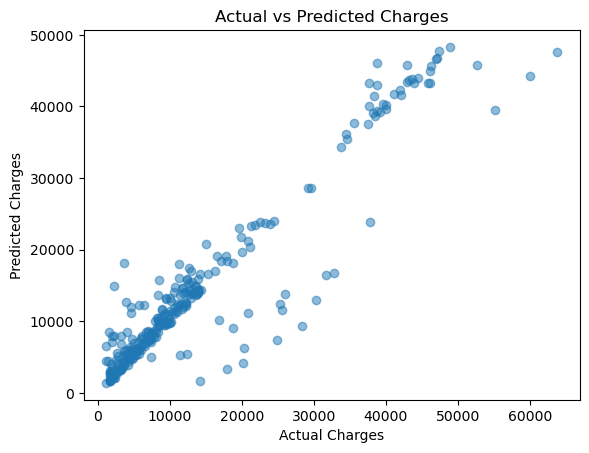

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()
